<a href="https://colab.research.google.com/github/VioletaPazCo/sprint13_vc/blob/main/b2g_medallion_pipeline_etl_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


# ENDOLLA B2G: Medallion Pipeline & Infrastructure Governance


---


---

# BRONZE — Ingestion & Unification

---

In [25]:
# 1. ENVIRONMENT SETUP & GLOBAL DEPENDENCIES
# ==============================================================================

# Standard Library & System Utilities
import calendar
import glob
import io
import os
import shutil
import zipfile

# Data Manipulation & Numerical Computation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Cloud & Environment Integration
from google.colab import drive
from google.colab import files as colab_files

# Global Options & Path Configuration
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_columns', None)
# sns.set_theme(style="whitegrid")

PATH_PREFIX = "/content/drive/MyDrive/Colab Notebooks/project/"

# Mount Google Drive
drive.mount('/content/drive')

print("=== Environment successfully initialized ===")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Environment successfully initialized ===


In [26]:
# 2. Functions - Bronze
# ==============================================================================

def parse_json_string(content: str) -> pd.DataFrame:
  """
  Parses JSON string using standard parser with NDJSON fallback.
  """
  try:
    return pd.read_json(io.StringIO(content))
  except ValueError:
    return pd.read_json(io.StringIO(content), lines=True)


def load_zip_jsons(file_list: list) -> pd.DataFrame:
  """
  Extracts and concatenates JSON files from a list of ZIP archives.
  """
  raw_dfs = []
  for file_path in file_list:
    if not os.path.exists(file_path):
      print(f"Warning: File not found at {file_path}")
      continue
    with zipfile.ZipFile(file_path, 'r') as z:
      json_files = [f for f in z.namelist() if f.endswith('.json')]
      if json_files:
        with z.open(json_files[0]) as f:
          content = f.read().decode('utf-8')
          raw_dfs.append(parse_json_string(content))
  return pd.concat(raw_dfs, ignore_index=True) if raw_dfs else pd.DataFrame()

In [27]:
# 3. Raw Locations & Telemetry Ingestion
# ==============================================================================

print("=== [BRONZE LAYER] INGESTING RAW LOCATIONS & TELEMETRY DATA ===")

# 1. Discover .zip archives
loc_zip_files = sorted(glob.glob(f"{PATH_PREFIX}*locations*.zip"))
telemetry_zip_files = sorted(glob.glob(f"{PATH_PREFIX}*estat_ports*.zip"))

# 2. Extract and concatenate historical datasets
df_loc_raw = load_zip_jsons(loc_zip_files)
df_telemetry_raw = load_zip_jsons(telemetry_zip_files)

# 3. Ingest uncompressed JSON snapshots not present in the .zip
loc_json_path = f"{PATH_PREFIX}locations_punts_recarrega.json"
telemetry_json_path = f"{PATH_PREFIX}estat_ports_realtime.json"

# 4. Concatenate locations dataset
if os.path.exists(loc_json_path):
  df_loc_extra = pd.read_json(loc_json_path)
  df_loc_raw = pd.concat([df_loc_raw, df_loc_extra], ignore_index=True)

# 5. COncatenate telemetry dataset
if os.path.exists(telemetry_json_path):
  df_telemetry_extra = pd.read_json(telemetry_json_path)
  df_telemetry_raw = pd.concat([df_telemetry_raw, df_telemetry_extra], ignore_index=True)

# 6. Ingestion Summary Audit
print(f"Total Raw Locations Ingested: {len(df_loc_raw):,} records.")
print(f"Total Raw Telemetry Ingested: {len(df_telemetry_raw):,} records.")

=== [BRONZE LAYER] INGESTING RAW LOCATIONS & TELEMETRY DATA ===
Total Raw Locations Ingested: 1,805 records.
Total Raw Telemetry Ingested: 1,668 records.


---
# SILVER — Cleansing & Structuring
---

## 1 Dimension Structuring

**Objective:** Unnest the hierarchical catalog structure (*Location -> Station -> Port*) from raw JSON files, build surrogate primary keys, and generate normalized dimension tables in a Star Schema format.

* `df_silver_dim_ports_history` (SCD Type 2 Tracking) - Retains historical configuration changes across charging infrastructure.
* `df_silver_dim_ports` - (Static Snapshot Dimension) Deduplicates records via composite key (`station_port_sk`) to capture the latest known state of each connector.
* **Schema Pruning:** Cleanses timestamp attributes and eliminates uninformative, zero-variance columns.

In [28]:
# 1. Catalog Processing & Dimension Generation (Modern Standard Pipeline)
# ==============================================================================

# 1. 3-Tier Catalog Flattening (Location -> Station -> Port)
df_loc_flat = pd.json_normalize(df_loc_raw["locations"], sep="_")

df_stations_exp = df_loc_flat.explode("stations").dropna(subset=["stations"]).reset_index(drop=True)
stations_flat = pd.json_normalize(df_stations_exp["stations"], sep="_").add_prefix("station_")
df_loc_stations = pd.concat([df_stations_exp.drop(columns=["stations"]), stations_flat], axis=1)

df_ports_exp = df_loc_stations.explode("station_ports").dropna(subset=["station_ports"]).reset_index(drop=True)
ports_flat = pd.json_normalize(df_ports_exp["station_ports"], sep="_").add_prefix("port_")
df_dim_ports_full = pd.concat([df_ports_exp.drop(columns=["station_ports"]), ports_flat], axis=1)

# 2. Key Standardization & Legacy Data Depuration
catalog_rename = {"id": "location_id", "station_id": "station_id", "port_id": "port_id"}
df_silver_dim_ports_history = df_dim_ports_full.rename(columns=catalog_rename).copy()

for col in ["location_id", "station_id", "port_id"]:
  if col in df_silver_dim_ports_history.columns:
    df_silver_dim_ports_history = df_silver_dim_ports_history.dropna(subset=[col])
    df_silver_dim_ports_history[col] = df_silver_dim_ports_history[col].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

# Filter out legacy port IDs > 57 and non-standard station IDs
df_silver_dim_ports_history["port_id_num"] = pd.to_numeric(df_silver_dim_ports_history["port_id"], errors="coerce")
df_silver_dim_ports_history = (
  df_silver_dim_ports_history[
    (df_silver_dim_ports_history["port_id_num"] >= 1) &
    (df_silver_dim_ports_history["port_id_num"] <= 57) &
    (df_silver_dim_ports_history["station_id"].str.len() == 5)
  ]
  .drop(columns=["port_id_num"])
  .reset_index(drop=True)
)

# Natural Surrogate Key Creation (station_id + port_id)
df_silver_dim_ports_history["station_port_sk"] = (
  df_silver_dim_ports_history["station_id"] + "_" + df_silver_dim_ports_history["port_id"]
  )

# Postal Code Normalization (Zero-padding to enforce 5-digit standard)
if "address_postal_code" in df_silver_dim_ports_history.columns:
  df_silver_dim_ports_history["address_postal_code"] = (
    df_silver_dim_ports_history["address_postal_code"]
    .dropna()
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
    .str.zfill(5)
    )

# 3. Inline Flattening for Authentications (1:1 with Ports)
auth_col = "port_port_authentications" if "port_port_authentications" in df_silver_dim_ports_history.columns else "port_authentications"
if auth_col in df_silver_dim_ports_history.columns:
  auth_series = df_silver_dim_ports_history[auth_col].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)
  auth_df = pd.json_normalize(auth_series).add_prefix("auth_")
  df_silver_dim_ports_history = pd.concat([df_silver_dim_ports_history.drop(columns=[auth_col]), auth_df], axis=1)

# 4. Timestamp Sanitization
ts_cols = ["last_updated", "port_last_updated", "station_last_updated"]
epoch_threshold = pd.Timestamp("1971-01-01", tz="UTC")
for col in ts_cols:
  if col in df_silver_dim_ports_history.columns:
    df_silver_dim_ports_history[col] = pd.to_datetime(df_silver_dim_ports_history[col], utc=True, errors="coerce")
    df_silver_dim_ports_history.loc[df_silver_dim_ports_history[col] < epoch_threshold, col] = pd.NaT

# Derive Use-Case Synthetic Attribute (Silver Layer Dimensional Enrichment)
is_moto = df_silver_dim_ports_history["port_notes"].fillna("") == "MOTORCYCLE_ONLY"
is_onstreet = df_silver_dim_ports_history["onstreet_location"] == True

df_silver_dim_ports_history["use_case"] = (
  is_onstreet.map({True: "On-Street", False: "Off-Street"}) + " " +
  is_moto.map({True: "Moto", False: "General"})
)

# 5. Column Pruning & Selection
cols_to_drop = [
  "network_brand_name", "network_name", "access_restriction", "language_code", "contact_operator_phone",
  "contact_operator_website", "address_admin_area", "address_country_code", "address_language_code",
  "host_name", "host_address_address_string", "host_address_locality", "host_address_postal_code",
  "host_address_country_code", "host_address_language_code", "host_contact_operator_phone",
  "host_contact_operator_website", "opening_hours", "opening_hours_weekday_begin", "opening_hours_weekday_end",
  "opening_hours_hour_begin", "opening_hours_hour_end", "port_port_status", "port_status",
  "coordinates_latitude", "coordinates_longitude"
]

silver_dim_column_order = [
  "station_port_sk", "location_id", "station_id", "port_id", "use_case", "onstreet_location", "address_address_string",
  "address_locality", "address_postal_code", "station_label", "station_notes", "station_coordinates_latitude",
  "station_coordinates_longitude", "station_last_updated", "port_connector_type", "port_power_kw",
  "port_charging_mechanism", "port_reservable", "auth_authentication_id", "auth_payment_required",
  "port_notes", "port_last_updated", "last_updated"
]

# Prune and reorder historical dimension
df_silver_dim_ports_history = df_silver_dim_ports_history.drop(columns=[c for c in cols_to_drop if c in df_silver_dim_ports_history.columns], errors="ignore")
existing_cols = [c for c in silver_dim_column_order if c in df_silver_dim_ports_history.columns]
df_silver_dim_ports_history = df_silver_dim_ports_history[existing_cols]

# 6. Generate Static Dimension (Star Schema Model - Latest Port Snapshot)
date_sort_col = "port_last_updated" if "port_last_updated" in df_silver_dim_ports_history.columns else "last_updated"
df_silver_dim_ports = (
  df_silver_dim_ports_history
  .sort_values(by=date_sort_col, ascending=False, na_position="last")
  .drop_duplicates(subset=["station_port_sk"], keep="first")
  .reset_index(drop=True)
)

# 7. Dimension Processing Summary Output
print("=== SILVER - DIMENSION TABLES AUDIT ===")
print(f"Historical Dimension (SCD Type 2): {df_silver_dim_ports_history.shape[0]:,} rows | {df_silver_dim_ports_history.shape[1]} columns")
print(f"Static Dimension (Star Schema):    {df_silver_dim_ports.shape[0]:,} rows | {df_silver_dim_ports.shape[1]} columns")
print(f"Unique Ports (station_port_sk):    {df_silver_dim_ports['station_port_sk'].nunique():,} active physical assets")

=== SILVER - DIMENSION TABLES AUDIT ===
Historical Dimension (SCD Type 2): 16,198 rows | 22 columns
Static Dimension (Star Schema):    1,796 rows | 22 columns
Unique Ports (station_port_sk):    1,796 active physical assets


## 2 Fact Structuring

**Objective:** Process incoming status telemetry streams, extract timestamps, construct classification targets, and route non-compliant records to governance quarantine buckets.

* `df_silver_fact_status` – Normalizes raw status values, corrects source-level typos (e.g., `UNKOWN`), and derives the binary target (`target_is_available`).
* **Governance Quarantine:** Routes quality violations to isolated quarantine tables without loss of historical record:
  * `df_quarantine_orphans_enriched`: Telemetry records referencing uncataloged ports.
  * `df_quarantine_epoch_errors`: Records containing invalid timestamps (< 2023).

In [29]:
# 2.1 Functions - Silver Telemetry
# ==============================================================================

def extract_status(val) -> str:
  """
  Safely extracts connector status string from nested dictionary/list objects or raw strings.
  """
  if isinstance(val, list) and len(val) > 0 and isinstance(val[0], dict):
    return val[0].get('status', None)
  return val if isinstance(val, str) else None


In [30]:
# 2.2 Telemetry Processing & Fact Table Generation (Modern Standard Pipeline)
# ==============================================================================

# 1. Telemetry 3-Tier Unnesting (Location -> Station -> Port)
df_tel_loc = pd.json_normalize(df_telemetry_raw["locations"], sep="_")

df_tel_stat_exp = df_tel_loc.explode("stations").dropna(subset=["stations"]).reset_index(drop=True)
tel_stat_flat = pd.json_normalize(df_tel_stat_exp["stations"], sep="_").add_prefix("station_")
df_tel_stations = pd.concat([df_tel_stat_exp.drop(columns=["stations"]), tel_stat_flat], axis=1)

ports_col = "ports" if "ports" in df_tel_stations.columns else "station_ports"
df_tel_ports_exp = df_tel_stations.explode(ports_col).dropna(subset=[ports_col]).reset_index(drop=True)
tel_ports_flat = pd.json_normalize(df_tel_ports_exp[ports_col], sep="_").add_prefix("port_")
df_tel_full = pd.concat([df_tel_ports_exp.drop(columns=[ports_col]), tel_ports_flat], axis=1)

# 2. Key Standardization & Legacy Data Depuration
tel_rename = {"id": "location_id", "station_id": "station_id", "port_id": "port_id", "port_last_updated": "event_timestamp"}
df_tel_full = df_tel_full.rename(columns=tel_rename)

for k in ["location_id", "station_id", "port_id"]:
  if k in df_tel_full.columns:
    df_tel_full = df_tel_full.dropna(subset=[k])
    df_tel_full[k] = df_tel_full[k].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

# Natural Surrogate Key Creation (station_id + port_id)
df_tel_full["station_port_sk"] = df_tel_full["station_id"] + "_" + df_tel_full["port_id"]

# 3. Status Extraction, Typo Correction & Binary Target Generation
status_col = next((c for c in ["port_port_status", "port_status"] if c in df_tel_full.columns), None)

df_tel_full["port_status_value"] = (df_tel_full[status_col].apply(extract_status) if status_col else "UNKNOWN")
df_tel_full["port_status_value"] = df_tel_full["port_status_value"].replace({"UNKOWN": "UNKNOWN"})

df_tel_full["target_is_available"] = (df_tel_full["port_status_value"] == "AVAILABLE").astype(int)

# 4. Datetime Conversion & Fact Schema Structuring
df_tel_full["event_timestamp_dt"] = pd.to_datetime(df_tel_full["event_timestamp"], utc=True, errors="coerce")

fact_column_order = [
  "station_port_sk", "location_id", "station_id", "port_id",
  "event_timestamp_dt", "port_status_value", "target_is_available"
]

df_fact_raw = (
  df_tel_full[fact_column_order]
  .dropna(subset=["station_port_sk", "event_timestamp_dt", "port_status_value"])
  .drop_duplicates(subset=["station_port_sk", "event_timestamp_dt"])
  .rename(columns={"event_timestamp_dt": "event_timestamp"})
  .reset_index(drop=True)
)

# 5. Quarantine Masking
master_locations = set(df_silver_dim_ports["location_id"].dropna().unique())
master_stations = set(df_silver_dim_ports["station_id"].dropna().unique())
master_ports = set(df_silver_dim_ports["station_port_sk"].dropna().unique())

is_valid_sk = df_fact_raw["station_port_sk"].isin(master_ports)
is_valid_timestamp = df_fact_raw["event_timestamp"].dt.year >= 2023

df_silver_fact_status = df_fact_raw[is_valid_sk & is_valid_timestamp].reset_index(drop=True)
df_quarantine_fact_orphans = df_fact_raw[~is_valid_sk].copy().reset_index(drop=True)
df_quarantine_epoch_errors = df_fact_raw[is_valid_sk & ~is_valid_timestamp].copy().reset_index(drop=True)

# 6. Quarantine Hierarchy Root Cause Audit Classification
loc_exists = df_quarantine_fact_orphans['location_id'].isin(master_locations)
st_exists = df_quarantine_fact_orphans['station_id'].isin(master_stations)

conditions = [
  loc_exists & st_exists,
  loc_exists & (~st_exists)
]

choices = [
  'Case A: Location & Station OK | Port Not Registered in Catalog',
  'Case B: Location OK | Station & Port Not Registered in Catalog'
]

df_quarantine_fact_orphans['quarantine_audit_case'] = np.select(
  conditions,
  choices,
  default='Case C: Location Not Found in Catalog (Unmapped Coordinates)'
)

# 7. Spatial Metadata & Infrastructure Catalog Enrichment
df_location_meta = df_silver_dim_ports[[
  'location_id', 'address_address_string', 'use_case', 'port_power_kw',
  'port_connector_type', 'port_charging_mechanism', 'onstreet_location',
  'address_postal_code', 'station_coordinates_latitude', 'station_coordinates_longitude'
]].drop_duplicates(subset=['location_id']).copy()

df_quarantine_orphans_enriched = df_quarantine_fact_orphans.merge(df_location_meta, on='location_id', how='left')

# Handling null attributes for Case C
df_quarantine_orphans_enriched['port_connector_type'] = df_quarantine_orphans_enriched['port_connector_type'].fillna('UNKNOWN (Case C)')
df_quarantine_orphans_enriched['use_case'] = df_quarantine_orphans_enriched['use_case'].fillna('Unclassified GPS')
df_quarantine_orphans_enriched['address_address_string'] = (
  df_quarantine_orphans_enriched['address_address_string']
  .fillna(df_quarantine_orphans_enriched['location_id'].apply(lambda x: f"Location ID: {x}"))
)

# Enriching Epoch Errors dataframe
df_quarantine_epoch_enriched = df_quarantine_epoch_errors.merge(
  df_silver_dim_ports[[
    'station_port_sk', 'address_address_string', 'use_case', 'port_power_kw',
    'port_connector_type', 'station_coordinates_latitude', 'station_coordinates_longitude'
  ]].drop_duplicates(subset=['station_port_sk']),
  on='station_port_sk',
  how='left'
)

# 8. Facts Processing Summary & Governance Audit
print("=== SILVER LAYER - FACT TABLE & GOVERNANCE QUARANTINE ===")
print(
  f"Silver Fact Table (df_silver_fact_status): "
  f"{len(df_silver_fact_status):,} records mapped across "
  f"{df_silver_fact_status['location_id'].nunique():,} locations"
)

print(
  f"Quarantine Fact Orphans (df_quarantine_orphans_enriched): "
  f"{len(df_quarantine_orphans_enriched):,} records mapped across "
  f"{df_quarantine_orphans_enriched['location_id'].nunique():,} locations "
  f"({df_quarantine_orphans_enriched['station_port_sk'].nunique():,} unique orphaned ports)"
)

print(
  f"Quarantine Epoch Errors (df_quarantine_epoch_enriched): "
  f"{len(df_quarantine_epoch_enriched):,} records mapped across "
  f"{df_quarantine_epoch_enriched['location_id'].nunique():,} locations "
  f"({df_quarantine_epoch_enriched['station_port_sk'].nunique():,} unique epoch error ports)"
)

=== SILVER LAYER - FACT TABLE & GOVERNANCE QUARANTINE ===
Silver Fact Table (df_silver_fact_status): 15,356 records mapped across 140 locations
Quarantine Fact Orphans (df_quarantine_orphans_enriched): 294 records mapped across 18 locations (37 unique orphaned ports)
Quarantine Epoch Errors (df_quarantine_epoch_enriched): 99 records mapped across 21 locations (99 unique epoch error ports)


## 3 Master Dataset Consolidation

**Objective:** Combine dimensional attributes with telemetry event status records into a unified master dataset (`df_master`), extract temporal features, enforce referential integrity via inner join, and automatically prune zero-variance columns.

* **Feature Engineering:** Derives temporal analytical variables (`year`, `month`, `day_of_week`, `hour`) directly from UTC event timestamps.
* **Automated Zero-Variance Depuration:** Detects and drops constant attributes (`nunique(dropna=False) == 1`) to ensure optimal feature space readiness for Gold Layer ingestion.

In [31]:
# 3. Master Model Consolidation & Feature Depuration (Modern Standard Pipeline)
# ==============================================================================

print("=== SILVER - CONSOLIDATING MASTER DATASET ===")

# 1. Feature Extraction from Fact Timestamps
df_fact = df_silver_fact_status.copy()
df_fact['year'] = df_fact['event_timestamp'].dt.year
df_fact['month'] = df_fact['event_timestamp'].dt.month
df_fact['day_of_week'] = df_fact['event_timestamp'].dt.dayofweek
df_fact['hour'] = df_fact['event_timestamp'].dt.hour

# 2. Prepare Dimension Columns (Avoid duplicating location_id, station_id, port_id from Fact)
dim_cols = [
  c for c in df_silver_dim_ports.columns
  if c not in ['location_id', 'station_id', 'port_id'] or c == 'station_port_sk'
]
df_dim_prepared = df_silver_dim_ports[dim_cols]

# 3. Inner Join (100% Referential Integrity via Silver Quarantine)
df_silver_master = pd.merge(df_fact, df_dim_prepared, on='station_port_sk', how='inner')

# 4. Enforce Logical Column Ordering
priority_cols = [
  'station_port_sk', 'location_id', 'station_id', 'port_id',
  'event_timestamp', 'year', 'month', 'day_of_week', 'hour',
  'port_status_value', 'target_is_available', 'use_case',
  'port_power_kw', 'port_connector_type', 'port_charging_mechanism', 'port_reservable',
  'onstreet_location', 'address_locality', 'address_postal_code',
  'station_coordinates_latitude', 'station_coordinates_longitude'
]

existing_priority = [c for c in priority_cols if c in df_silver_master.columns]
remaining_cols = [c for c in df_silver_master.columns if c not in existing_priority]
df_master = df_silver_master[existing_priority + remaining_cols]

# 5. Zero-Variance Cleansing (Automated Constant Feature Removal)
zero_variance_cols = [c for c in df_master.columns if df_master[c].nunique(dropna=False) == 1]

if zero_variance_cols:
  df_master = df_master.drop(columns=zero_variance_cols)
  print(f"Cleansed {len(zero_variance_cols)} zero-variance columns post-merge: {zero_variance_cols}")

# 6. Core Integrity Verifications
assert df_master[['station_port_sk', 'port_status_value', 'target_is_available']].isnull().sum().sum() == 0, 'Null values detected in core identifiers/targets!'

print(f"Silver Master Dataset Consolidated & Depurated (df_master): {df_master.shape[0]:,} rows × {df_master.shape[1]} columns.\n")
display(df_master.head(3))

=== SILVER - CONSOLIDATING MASTER DATASET ===
Cleansed 3 zero-variance columns post-merge: ['address_locality', 'auth_authentication_id', 'auth_payment_required']
Silver Master Dataset Consolidated & Depurated (df_master): 15,356 rows × 26 columns.



,station_port_sk,location_id,station_id,port_id,event_timestamp,year,month,day_of_week,hour,port_status_value,target_is_available,use_case,port_power_kw,port_connector_type,port_charging_mechanism,port_reservable,onstreet_location,address_postal_code,station_coordinates_latitude,station_coordinates_longitude,address_address_string,station_label,station_notes,port_notes,port_last_updated,last_updated
0,11316_1,3715,11316,1,2023-10-05 09:24:40+00:00,2023,10,3,9,AVAILABLE,1,Off-Street General,3.60,WALL_OUTLET,SOCKET,False,False,08004,41.37,2.15,"Av. Reina Maria Cristina, 16",MULT_RIUS1,Aparcament Ap. BSM - Rius i Taulet,,2025-12-23 11:33:38+00:00,2025-02-19 14:03:54+00:00
1,11316_2,3715,11316,2,2023-10-04 22:11:06+00:00,2023,10,2,22,AVAILABLE,1,Off-Street General,3.60,WALL_OUTLET,SOCKET,False,False,08004,41.37,2.15,"Av. Reina Maria Cristina, 16",MULT_RIUS1,Aparcament Ap. BSM - Rius i Taulet,,2025-12-23 11:33:38+00:00,2025-02-19 14:03:54+00:00
2,11316_3,3715,11316,3,2023-09-16 21:17:11+00:00,2023,9,5,21,AVAILABLE,1,Off-Street General,3.60,WALL_OUTLET,SOCKET,False,False,08004,41.37,2.15,"Av. Reina Maria Cristina, 16",MULT_RIUS1,Aparcament Ap. BSM - Rius i Taulet,,2025-12-23 11:33:38+00:00,2025-02-19 14:03:54+00:00


## 4 Quality & Governance Audit

---

### 1. Primary Key Collision & Natural Surrogate Key
* **Issue:** Global `port_id` values overlapped across different charging stations in the source schemas.
* **Solution:** Standardized a natural surrogate key (`station_port_sk = station_id + "_" + port_id`), establishing a clean 1:1 join mechanism across dimensions (`df_silver_dim_ports`) and facts (`df_silver_fact_status`).

### 2. Legacy System Depuration & Nomenclatural Alignment
* **Issue:** Legacy snapshot data (January 2023) contained global port IDs (> 57) that were replaced by a localized per-station standard (IDs 1–57) starting in June 2023, creating structural redundancy.
* **Solution:** Depurated non-standard legacy port IDs ($1 \le \text{port\_id} \le 57$) across all historical tables, eliminating the need for complex spatial deduplication keys and aligning the dimensional model directly with production telemetry.

### 3. Postal Code Formatting & Standardized Padding
* **Issue:** Inconsistent postal code string formats generated false cardinality expansion.
* **Solution:** Enforced a standard 5-digit zero-padded format (`zfill(5)`) for administrative and spatial consistency.

### 4. Target Binarization & Typo Normalization
* **Feature Engineering:** Corrected source-level string typos (e.g., mapping `'UNKOWN'` to `'UNKNOWN'`), standardized categorical status values (`port_status_value`), and derived the primary binary classification target (`target_is_available = 1` ONLY if status is `'AVAILABLE'`).

### 5. Unix Epoch Noise & Temporal Standardization
* **Issue:** Uninitialized IoT connectors and telemetry streaming anomalies emitted invalid Unix Epoch timestamps (`1970-01-01T00:00:00Z`).
* **Solution:** Converted all timestamps to UTC standard and enforced a temporal quality threshold (`event_timestamp >= 2023-01-01 UTC`).

### 6. Data Governance Quarantine & Orphan Tracking
* **Quality Assurance & Routing:** Implemented automated data quality masks to isolate invalid telemetry records without losing raw historical traceability:
  * `df_quarantine_fact_orphans` / `df_quarantine_orphans_enriched`: Captures telemetry pointing to uncataloged connectors, enriched with audit root-cause categories (Cases A, B, and C).
  * `df_quarantine_epoch_errors`: Isolates records failing temporal validity checks.

### 7. Zero-Variance Cleansing & Master Consolidation
* **Referential Integrity & Automated Depuration:** Consolidated dimensions and telemetry into `df_master` using an inner join (referential integrity guaranteed post-quarantine). Automated the removal of zero-variance columns (`nunique(dropna=False) == 1`) to deliver a clean, lean dataset ready for downstream analytics and machine learning modeling.


---


# GOLD — Business Intelligence & Network Audit

---



## 1 Static & Historical Dimension


In [32]:
# 1 Historical Dimension Analysis (Gold Layer)
# ==============================================================================

df_hist = df_silver_dim_ports_history.copy()
df_hist['last_updated'] = pd.to_datetime(df_hist['last_updated'], utc=True, errors='coerce')

# Extract update year from timestamp
df_hist['year_updated'] = df_hist['last_updated'].dt.year

print("=== 1.1 DIMENSIONAL HISTORICAL AUDIT ===")
print(f"Total Historical Snapshot Records (SCD Type 2): {len(df_hist):,}")
print(f"Total Unique Physical Ports (station_port_sk):  {df_hist['station_port_sk'].nunique():,}")
print(f"Total Unique Physical Locations (location_id):   {df_hist['location_id'].nunique():,}\n")


# 2. Build Yearly Cumulative Snapshots
years = sorted(df_hist['year_updated'].dropna().unique())
yearly_snapshots = []

for yr in years:
  mask = df_hist['year_updated'] <= yr
  df_until_yr = df_hist[mask].sort_values('last_updated')

  # Deduce the latest active state of each physical port up to that year
  latest_ports_yr = df_until_yr.groupby('station_port_sk').last().reset_index()
  latest_ports_yr['snapshot_year'] = int(yr)
  yearly_snapshots.append(latest_ports_yr)

df_cumulative_snapshots = pd.concat(yearly_snapshots, ignore_index=True)


# 3. Real Evolution of Infrastructure Deployment and Cumulative Metrics
first_seen_port = df_hist.groupby('station_port_sk')['year_updated'].min().reset_index()
first_seen_location = df_hist.groupby('location_id')['year_updated'].min().reset_index()

# Track cumulative unique locations added per year
locations_by_year = (
  first_seen_location
  .groupby('year_updated')
  .size()
  .reset_index(name='new_locations_added')
  .rename(columns={'year_updated': 'year'})
)
locations_by_year['cum_unique_locations'] = locations_by_year['new_locations_added'].cumsum()

# Track new physical ports added per year
new_ports_by_year = (
  first_seen_port
  .groupby('year_updated')
  .size()
  .reset_index(name='new_ports_added')
  .rename(columns={'year_updated': 'year'})
)
new_ports_by_year['cum_total_ports'] = new_ports_by_year['new_ports_added'].cumsum()

# Track installed capacity (kW) based on yearly physical snapshots
power_evolution = (
  df_cumulative_snapshots
  .groupby('snapshot_year')
  .agg(total_installed_kw=('port_power_kw', 'sum'))
  .reset_index()
  .rename(columns={'snapshot_year': 'year'})
)

# Merge all historical metrics into summary table
summary_table_gold = (
  locations_by_year[['year', 'cum_unique_locations']]
  .merge(new_ports_by_year, on='year')
  .merge(power_evolution, on='year')
)

# Cumulative percentage of total power installed
final_total_kw = summary_table_gold['total_installed_kw'].iloc[-1]
summary_table_gold['cum_power_pct'] = (summary_table_gold['total_installed_kw'] / final_total_kw) * 100

print("=== 1.2 HISTORICAL EVOLUTION OF PHYSICAL INFRASTRUCTURE ===")
display(summary_table_gold.style.hide().format({
  'total_installed_kw': '{:.2f}',
  'cum_power_pct': '{:.2f}%'
}))

# 4. Cumulative Connector Mix By Year
connector_mix_gold = pd.crosstab(
  df_cumulative_snapshots['snapshot_year'],
  df_cumulative_snapshots['port_connector_type']
)
connector_mix_gold['Total_Active_Ports'] = connector_mix_gold.sum(axis=1)

print("\n=== 1.3 CUMULATIVE CONNECTOR MIX BY YEAR ===")
display(connector_mix_gold)


# 5. Cumulative Use-Case Distribution By Year
use_case_cumulative_gold = pd.crosstab(
  df_cumulative_snapshots['snapshot_year'],
  df_cumulative_snapshots['use_case']
)
use_case_cumulative_gold['Total_Active_Ports'] = use_case_cumulative_gold.sum(axis=1)

print("\n=== 1.4 CUMULATIVE USE-CASE DISTRIBUTION BY YEAR ===")
display(use_case_cumulative_gold)

# Integrity Verification
assert df_cumulative_snapshots['station_port_sk'].isnull().sum() == 0, 'Null keys detected in cumulative snapshots!'

=== 1.1 DIMENSIONAL HISTORICAL AUDIT ===
Total Historical Snapshot Records (SCD Type 2): 16,198
Total Unique Physical Ports (station_port_sk):  1,796
Total Unique Physical Locations (location_id):   140

=== 1.2 HISTORICAL EVOLUTION OF PHYSICAL INFRASTRUCTURE ===


year,cum_unique_locations,new_ports_added,cum_total_ports,total_installed_kw,cum_power_pct
2023,135,1532,1532,12015.64,87.16%
2024,138,108,1640,12492.84,90.62%
2025,139,149,1789,13798.12,100.09%
2026,140,7,1796,13786.36,100.00%



=== 1.3 CUMULATIVE CONNECTOR MIX BY YEAR ===


port_connector_type,CCS_TYPE_2,CHADEMO,MENNEKES,WALL_OUTLET,Total_Active_Ports
snapshot_year,,,,,
2023,54,52,2,1424,1532
2024,55,53,2,1530,1640
2025,55,53,2,1679,1789
2026,56,54,2,1684,1796



=== 1.4 CUMULATIVE USE-CASE DISTRIBUTION BY YEAR ===


use_case,Off-Street General,Off-Street Moto,On-Street General,On-Street Moto,Total_Active_Ports
snapshot_year,,,,,
2023,751,416,163,202,1532
2024,790,478,166,206,1640
2025,856,553,172,208,1789
2026,857,552,175,212,1796


In [33]:
# 2 Static Dimension Analysis (Gold Layer)
# ==============================================================================

df_static = df_silver_dim_ports.copy()

df_static['last_updated'] = pd.to_datetime(df_static['last_updated'], errors='coerce')
min_date = df_static['last_updated'].min().strftime('%Y-%m-%d')
max_date = df_static['last_updated'].max().strftime('%Y-%m-%d')

# 1. Catalog Temporal Range & Footprint Baseline
print("=== 2.1 STATIC CATALOG BASELINE & TEMPORAL COVERAGE ===")
print(f"Static Catalog Historical Range:             {min_date} to {max_date}")
print(f"Total Active Physical Ports:                 {len(df_static):,}")
print(f"Total Unique Charging Stations:              {df_static['station_id'].nunique():,}")
print(f"Total Unique Administrative Locations:       {df_static['location_id'].nunique():,}")
print(f"Total Postal Code Districts Covered:         {df_static['address_postal_code'].nunique():,}\n")

# 2. Connector vs Power Distribution (Current Snapshot)
connector_power_static = pd.crosstab(
  df_static['port_connector_type'],
  df_static['port_power_kw'],
  margins=True,
  margins_name='Total'
)

print("=== 2.2 CONNECTOR vs POWER DISTRIBUTION ===")
display(connector_power_static)

# 3. Station Infrastructure Density Analysis
ports_per_station = df_static.groupby('station_id')['port_id'].count()

print("\n=== 2.3 STATION INFRASTRUCTURE DENSITY ===")
print(f"Median Ports per Station:      {ports_per_station.median():.2f}")
print(f"Max Ports in a Single Station: {ports_per_station.max()}")
print(f"Min Ports in a Single Station: {ports_per_station.min()}")

# 4. Location Infrastructure Density Analysis
ports_per_location = df_static.groupby('location_id')['port_id'].count()

print("\n=== 2.4 LOCATION INFRASTRUCTURE DENSITY ===")
print(f"Median Ports per Location:      {ports_per_location.median():.2f}")
print(f"Max Ports in a Single Location: {ports_per_location.max()}")
print(f"Min Ports in a Single Location: {ports_per_location.min()}")

# Core Integrity Verification
assert len(df_static) == df_static['station_port_sk'].nunique(), 'Duplicates detected in static dimension unique surrogate key!'

=== 2.1 STATIC CATALOG BASELINE & TEMPORAL COVERAGE ===
Static Catalog Historical Range:             2023-06-26 to 2026-07-16
Total Active Physical Ports:                 1,796
Total Unique Charging Stations:              943
Total Unique Administrative Locations:       140
Total Postal Code Districts Covered:         39

=== 2.2 CONNECTOR vs POWER DISTRIBUTION ===


port_power_kw,3.20,3.60,3.68,7.20,7.36,22.00,43.00,44.00,50.00,Total
port_connector_type,,,,,,,,,,
CCS_TYPE_2,0,0,0,0,0,0,0,0,56,56
CHADEMO,0,0,0,0,0,0,0,0,54,54
MENNEKES,0,0,0,0,0,1,1,1,0,3
WALL_OUTLET,1,1276,1,350,1,54,0,0,0,1683
Total,1,1276,1,350,1,55,1,1,110,1796



=== 2.3 STATION INFRASTRUCTURE DENSITY ===
Median Ports per Station:      1.00
Max Ports in a Single Station: 57
Min Ports in a Single Station: 1

=== 2.4 LOCATION INFRASTRUCTURE DENSITY ===
Median Ports per Location:      5.00
Max Ports in a Single Location: 127
Min Ports in a Single Location: 2


## 2 Telemetry Fact & Governance Audit

### 2.1 Operational Network Analysis

In [34]:
# 2.1.1 Baseline & Temporal Profiling (Telemetry Fact Analysis)
# ==============================================================================

df_fact = df_master.copy()
df_fact['day_of_week_name'] = df_fact['event_timestamp'].dt.day_name()

min_date_fact = df_fact['event_timestamp'].min().strftime('%Y-%m-%d %H:%M')
max_date_fact = df_fact['event_timestamp'].max().strftime('%Y-%m-%d %H:%M')

print("=== 2.1.1 TELEMETRY FACT BASELINE & COVERAGE ===")
print(f"Historical Range:                  {min_date_fact} to {max_date_fact}")
print(f"Total Fact Events:                 {len(df_fact):,}")
print(f"Unique Active Ports:               {df_fact['station_port_sk'].nunique():,}")
print(f"Unique Active Stations:            {df_fact['station_id'].nunique():,}")
print(f"Unique Active Locations:           {df_fact['location_id'].nunique():,}\n")

# 1. Annual Telemetry Coverage
annual_telemetry = (
  df_fact.groupby('year')
  .agg(
    total_events=('event_timestamp', 'count'),
    unique_active_ports=('station_port_sk', 'nunique'),
    unique_stations=('station_id', 'nunique')
  ).reset_index()
)

annual_telemetry['pct_of_total_events'] = (annual_telemetry['total_events'] / len(df_fact)) * 100

print("=== 2.1.2 ANNUAL EVENT & PORT COVERAGE ===")
display(annual_telemetry.style.hide().format({
  'total_events': '{:,}',
  'unique_active_ports': '{:,}',
  'unique_stations': '{:,}',
  'pct_of_total_events': '{:.2f}%'
}))

# 2. Global Availability Breakdown
target_distribution = df_fact['target_is_available'].value_counts().to_frame("Event_Count")
target_distribution["Percentage (%)"] = (df_fact['target_is_available'].value_counts(normalize=True) * 100).round(2)
target_distribution.index = ["Available (1)", "Occupied/Unavailable (0)"]

print("\n=== 2.1.3 GLOBAL TARGET AVAILABILITY BREAKDOWN ===")
display(target_distribution)

# 3. Temporal Distributions Prep
month_dist = df_fact['month'].value_counts().sort_index().to_frame("Event_Count")
month_dist["Percentage (%)"] = (df_fact['month'].value_counts(normalize=True).sort_index() * 100).round(2)

cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_fact['day_of_week_name'] = pd.Categorical(df_fact['day_of_week_name'], categories=cats, ordered=True)
dow_dist = df_fact['day_of_week_name'].value_counts().sort_index().to_frame("Event_Count")
dow_dist["Percentage (%)"] = (df_fact['day_of_week_name'].value_counts(normalize=True).sort_index() * 100).round(2)

hour_dist = df_fact['hour'].value_counts().sort_index().to_frame("Event_Count")
hour_dist["Percentage (%)"] = (df_fact['hour'].value_counts(normalize=True).sort_index() * 100).round(2)

# Core Integrity Verification
assert df_fact[['station_port_sk', 'event_timestamp', 'target_is_available']].isnull().sum().sum() == 0, "Null values detected in core fact columns!"

=== 2.1.1 TELEMETRY FACT BASELINE & COVERAGE ===
Historical Range:                  2023-08-10 05:21 to 2026-07-28 16:57
Total Fact Events:                 15,356
Unique Active Ports:               1,780
Unique Active Stations:            933
Unique Active Locations:           140

=== 2.1.2 ANNUAL EVENT & PORT COVERAGE ===


year,total_events,unique_active_ports,unique_stations,pct_of_total_events
2023,"1,040",941,353,6.77%
2024,"5,061","1,419",729,32.96%
2025,"6,502","1,496",877,42.34%
2026,"2,753","1,345",862,17.93%



=== 2.1.3 GLOBAL TARGET AVAILABILITY BREAKDOWN ===


,Event_Count,Percentage (%)
Available (1),11859,77.23
Occupied/Unavailable (0),3497,22.77


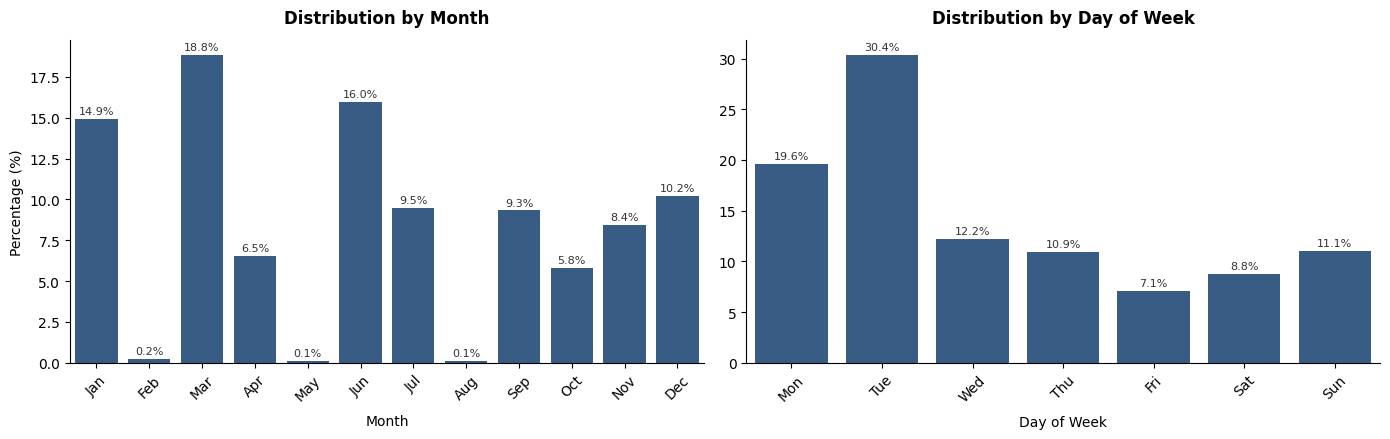

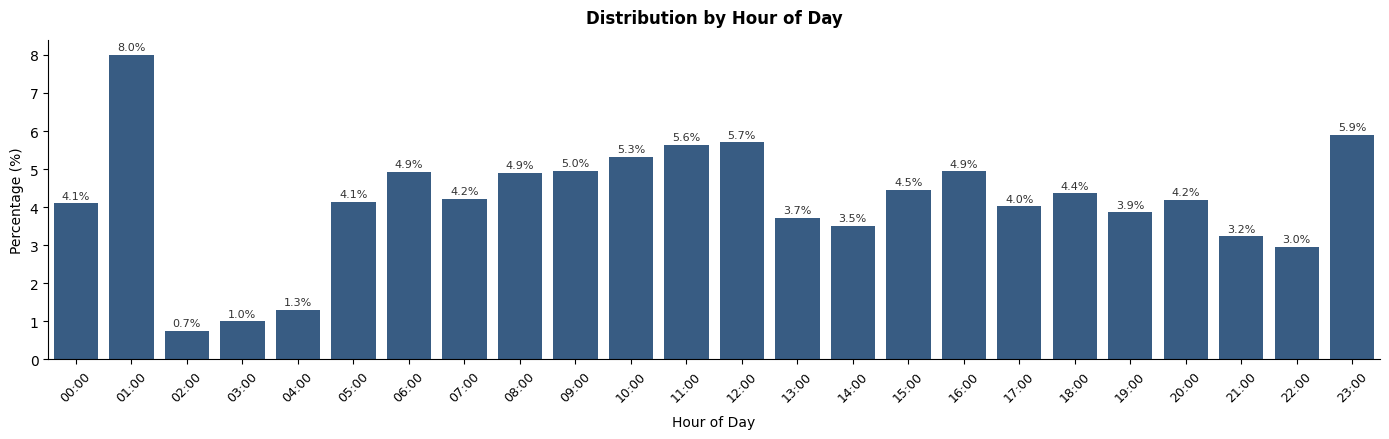

In [35]:
# 2.1.2 Temporal Distribution Charts
# ==============================================================================

# 1. Monthly & Weekly Distributions (1x2 Plot)
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 4.5))
palette_color = "#2b5c8f"

# Monthly plot
month_labels = [calendar.month_abbr[m] for m in month_dist.index]
sns.barplot(x=month_labels, y=month_dist['Percentage (%)'], ax=axes1[0], color=palette_color)
axes1[0].set_title('Distribution by Month', fontsize=12, fontweight='bold', pad=12)
axes1[0].set_xlabel('Month', fontsize=10, labelpad=8)
axes1[0].set_ylabel('Percentage (%)', fontsize=10)
axes1[0].tick_params(axis='x', rotation=45)

# Weekly plot
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.barplot(x=day_labels, y=dow_dist['Percentage (%)'], ax=axes1[1], color=palette_color)
axes1[1].set_title('Distribution by Day of Week', fontsize=12, fontweight='bold', pad=12)
axes1[1].set_xlabel('Day of Week', fontsize=10, labelpad=8)
axes1[1].set_ylabel('')
axes1[1].tick_params(axis='x', rotation=45)

for ax in axes1:
  sns.despine(ax=ax, top=True, right=True)
  for p in ax.patches:
    height = p.get_height()
    if height > 0:
      ax.annotate(f'{height:.1f}%',
                  (p.get_x() + p.get_width() / 2., height),
                  ha='center', va='bottom',
                  fontsize=8, color='#333333',
                  xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\n")

# 2. Hourly Distribution Plot
fig2, ax2 = plt.subplots(figsize=(14, 4.5))
hour_labels = [f"{h:02d}:00" for h in hour_dist.index]
sns.barplot(x=hour_labels, y=hour_dist['Percentage (%)'], ax=ax2, color=palette_color)
ax2.set_title('Distribution by Hour of Day', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Hour of Day', fontsize=10, labelpad=8)
ax2.set_ylabel('Percentage (%)', fontsize=10)
ax2.tick_params(axis='x', rotation=45, labelsize=9)

sns.despine(ax=ax2, top=True, right=True)
for p in ax2.patches:
  height = p.get_height()
  if height > 0:
    ax2.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=8, color='#333333',
                xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

### 2.2 Quarantined Network Analysis

In [36]:
# 2.2.1 Orphan Records Audit: Root Cause & Profiling (Gold Layer)
# ==============================================================================

# 1. Root Cause Breakdown Table
audit_df = (
  df_quarantine_orphans_enriched
  .groupby('quarantine_audit_case')
  .agg(
    event_count=('station_port_sk', 'count'),
    unique_ports=('station_port_sk', 'nunique')
  )
  .reset_index()
  .rename(columns={'quarantine_audit_case': 'Audit Case / Root Cause'})
  .sort_values(by='event_count', ascending=False)
)

audit_df['Percentage (%)'] = (audit_df['event_count'] / len(df_quarantine_orphans_enriched)) * 100

# Map spatial coordinate availability based on audit classification
audit_df['Mapped Coordinates'] = audit_df['Audit Case / Root Cause'].apply(
    lambda x: 'No (Excluded from Map)' if str(x).startswith('Case C') else 'Yes (Location Mapped)'
)

audit_df = audit_df[[
  'Audit Case / Root Cause',
  'event_count',
  'Percentage (%)',
  'Mapped Coordinates',
  'unique_ports',
]]

print("=== 2.2.1 QUARANTINE ROOT CAUSE BREAKDOWN ===")
display(
  audit_df.style
  .format({
    'event_count': '{:,}',
    'unique_ports': '{:,}',
    'Percentage (%)': '{:.2f}%'
  })
  .hide(axis='index')
)

# 2. Infrastructure & Power Metrics
power_series = df_quarantine_orphans_enriched['port_power_kw'].dropna()

min_p = power_series.min() if not power_series.empty else 0
med_p = power_series.median() if not power_series.empty else 0
max_p = power_series.max() if not power_series.empty else 0
iqr_p = (power_series.quantile(0.75) - power_series.quantile(0.25)) if not power_series.empty else 0

print("\n=== 2.2.2 ORPHAN INFRASTRUCTURE & POWER METRICS ===")
print(f"Total Orphan Events:             {len(df_quarantine_orphans_enriched):,}")
print(f"Unique Locations Affected:       {df_quarantine_orphans_enriched['location_id'].nunique():,}")
print(f"Unique Emitting Stations:        {df_quarantine_orphans_enriched['station_id'].nunique():,}")
print(f"Unique Emitting Ports:           {df_quarantine_orphans_enriched['station_port_sk'].nunique():,}")
print(f"Unique Postal Codes:             {df_quarantine_orphans_enriched['address_postal_code'].dropna().nunique():,}")
print(f"Power Range (Min / Med / Max):   {min_p:.1f} kW / {med_p:.1f} kW / {max_p:.1f} kW (IQR: {iqr_p:.1f} kW)")

# 3. Technical Connector Breakdown (Filling missing values with 'UNKNOWN')
tech_cols = ['port_connector_type', 'port_charging_mechanism', 'use_case']
df_quarantine_orphans_enriched[tech_cols] = df_quarantine_orphans_enriched[tech_cols].fillna('UNKNOWN')

tech_breakdown = (
  df_quarantine_orphans_enriched
  .groupby(tech_cols)
  .agg(
    event_count=('station_port_sk', 'count'),
    unique_ports=('station_port_sk', 'nunique')
  )
  .reset_index()
  .sort_values(by='event_count', ascending=False)
)

tech_breakdown['pct_of_orphan_events'] = (tech_breakdown['event_count'] / len(df_quarantine_orphans_enriched)) * 100

print("\n=== 2.2.3 CONNECTOR & USE CASE BREAKDOWN ===")
display(
  tech_breakdown.style
  .format({
    'event_count': '{:,}',
    'unique_ports': '{:,}',
    'pct_of_orphan_events': '{:.2f}%'
  })
  .hide(axis='index')
)

=== 2.2.1 QUARANTINE ROOT CAUSE BREAKDOWN ===


Audit Case / Root Cause,event_count,Percentage (%),Mapped Coordinates,unique_ports
Case B: Location OK | Station & Port Not Registered in Catalog,214,72.79%,Yes (Location Mapped),25
Case C: Location Not Found in Catalog (Unmapped Coordinates),66,22.45%,No (Excluded from Map),8
Case A: Location & Station OK | Port Not Registered in Catalog,14,4.76%,Yes (Location Mapped),4



=== 2.2.2 ORPHAN INFRASTRUCTURE & POWER METRICS ===
Total Orphan Events:             294
Unique Locations Affected:       18
Unique Emitting Stations:        26
Unique Emitting Ports:           37
Unique Postal Codes:             13
Power Range (Min / Med / Max):   3.6 kW / 3.6 kW / 50.0 kW (IQR: 3.6 kW)

=== 2.2.3 CONNECTOR & USE CASE BREAKDOWN ===


port_connector_type,port_charging_mechanism,use_case,event_count,unique_ports,pct_of_orphan_events
WALL_OUTLET,SOCKET,Off-Street General,212,23,72.11%
UNKNOWN (Case C),UNKNOWN,Unclassified GPS,66,8,22.45%
CHADEMO,CABLE,On-Street General,14,4,4.76%
WALL_OUTLET,SOCKET,On-Street General,2,2,0.68%


In [37]:
# 2.2.2 Orphan Records Audit: Case A & Case B Drill-down
# ==============================================================================

# 1. Case A Port Discrepancy Analysis (Location & Station OK | Port Missing)
case_a_events = df_quarantine_orphans_enriched[
  df_quarantine_orphans_enriched['quarantine_audit_case'].str.startswith('Case A', na=False)
]
case_a_stations = case_a_events['station_id'].dropna().unique()

master_ports_case_a = (
  df_silver_dim_ports[df_silver_dim_ports['station_id'].isin(case_a_stations)]
  [['location_id', 'station_id', 'port_id']]
  .drop_duplicates()
)

emitted_ports_case_a = (
  case_a_events
  .groupby(['location_id', 'station_id'])
  .agg(
    quarantine_emitted_ports=('port_id', lambda x: sorted(list(set(x.dropna())))),
    quarantine_events=('event_timestamp', 'count')
  )
  .reset_index()
)

case_a_comparison = (
  master_ports_case_a
  .groupby(['location_id', 'station_id'])
  .agg(catalog_registered_ports=('port_id', lambda x: sorted(list(set(x.dropna())))))
  .reset_index()
  .merge(emitted_ports_case_a, on=['location_id', 'station_id'], how='inner')
  .sort_values(by='quarantine_events', ascending=False)
  .reset_index(drop=True)
)

case_a_comparison = case_a_comparison[[
  'location_id', 'station_id', 'catalog_registered_ports',
  'quarantine_emitted_ports', 'quarantine_events'
]]

# 2. Case B Unregistered Stations Analysis (Location OK | Station and Port Missing)
case_b_events = df_quarantine_orphans_enriched[df_quarantine_orphans_enriched['quarantine_audit_case'].str.startswith('Case B', na=False)]
case_b_locations = case_b_events['location_id'].dropna().unique()

master_stations_per_loc = (
  df_silver_dim_ports[df_silver_dim_ports['location_id'].isin(case_b_locations)]
  .groupby('location_id')['station_id']
  .apply(lambda x: sorted(list(set(x.dropna()))))
  .to_dict()
)

case_b_summary = (
  case_b_events
  .groupby('location_id')
  .agg(
    quarantine_emitting_stations=('station_id', lambda x: sorted(list(set(x.dropna())))),
    quarantine_events=('event_timestamp', 'count')
  )
  .reset_index()
)

case_b_summary['catalog_registered_stations'] = case_b_summary['location_id'].map(lambda loc: master_stations_per_loc.get(loc, []))

case_b_summary = (
  case_b_summary[[
    'location_id', 'catalog_registered_stations',
    'quarantine_emitting_stations', 'quarantine_events'
  ]]
  .sort_values(by='quarantine_events', ascending=False)
  .reset_index(drop=True)
)

print("=== CASE A: CATALOG vs TELEMETRY PORT DISCREPANCY ===")
display(case_a_comparison)

print("\n=== CASE B: UNREGISTERED PHYSICAL STATIONS AUDIT ===")
display(case_b_summary)

=== CASE A: CATALOG vs TELEMETRY PORT DISCREPANCY ===


,location_id,station_id,catalog_registered_ports,quarantine_emitted_ports,quarantine_events
0,3736,15667,[1],[2],7
1,3727,11302,"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20...",[2],5
2,3730,11311,"[1, 10, 2, 3, 4, 6, 7, 8, 9]",[5],1
3,3742,11303,"[1, 10, 11, 12, 2, 3, 5, 6, 7, 8, 9]",[4],1



=== CASE B: UNREGISTERED PHYSICAL STATIONS AUDIT ===


,location_id,catalog_registered_stations,quarantine_emitting_stations,quarantine_events
0,3733,"[11257, 11389, 11390, 11391, 11392, 13799, 138...","[11368, 11369]",48
1,3752,"[11200, 11201, 11202, 11291, 12227, 12228, 122...","[11198, 11199]",46
2,3738,"[11306, 11328, 11329, 11333, 11334, 11335, 130...","[11330, 11331, 11332]",36
3,3737,"[11314, 11336, 11337, 11338, 11339, 12569, 125...","[11340, 11341, 16283]",25
4,3723,"[11213, 11214, 11215, 11216, 11217, 11218, 11294]",[11219],12
5,3729,"[11278, 11279, 11307, 12548, 12549, 12550, 125...",[11280],12
6,3751,"[11281, 11282, 11283, 11284, 11286, 12304, 123...",[11285],12
7,3844,[11168],[17106],8
8,3795,"[11100, 11101, 11102, 11103]",[17243],6
9,3739,"[11274, 11275, 11277, 11313, 12997, 12998, 129...",[11276],6


In [38]:
# 2.2.3 Epoch Anomalies Audit: Sensor Failure & Operational Profiling
# ==============================================================================

# 1. Base Metrics Audit
total_epoch_events = len(df_quarantine_epoch_errors)
unique_epoch_locs = df_quarantine_epoch_errors['location_id'].dropna().nunique()
unique_epoch_stations = df_quarantine_epoch_errors['station_id'].dropna().nunique()
unique_epoch_ports = df_quarantine_epoch_errors['station_port_sk'].dropna().nunique()

print("=== TEMPORAL ANOMALIES & SENSOR FAILURE AUDIT ===")
print(f"Total Epoch Quarantine Events:   {total_epoch_events:,}")
print(f"Unique Affected Locations:       {unique_epoch_locs:,}")
print(f"Unique Emitting Stations:        {unique_epoch_stations:,}")
print(f"Unique Emitting Ports (SK):      {unique_epoch_ports:,}")

# 2. Map Valid Events Activity per Station and Port
valid_counts_per_port = df_silver_fact_status['station_port_sk'].value_counts().to_dict()

valid_events_per_station = (
  df_silver_fact_status
  .groupby('station_id')['station_port_sk']
  .count()
  .to_dict()
)

# 3. Station Level Operational Categorization
station_audit = (
  df_quarantine_epoch_errors
  .groupby(['location_id', 'station_id'])
  .agg(
    epoch_events=('station_port_sk', 'count'),
    affected_ports=('port_id', lambda x: sorted(list(set(x.dropna()))))
  )
  .reset_index()
)

station_audit['total_valid_events_station'] = station_audit['station_id'].map(lambda st_id: valid_events_per_station.get(st_id, 0))

# Segmentation by valid activity
stations_zero_valid = station_audit[station_audit['total_valid_events_station'] == 0]
stations_active_valid = station_audit[station_audit['total_valid_events_station'] > 0]

# Port Level Segmentation
ports_in_quarantine = df_quarantine_epoch_errors['station_port_sk'].dropna().unique()
ports_with_valid = sum(1 for sk in ports_in_quarantine if valid_counts_per_port.get(sk, 0) > 0)
ports_zero_valid = unique_epoch_ports - ports_with_valid

print("\n=== OPERATIONAL IMPACT & ACTIVITY BREAKDOWN ===")
print(f"Stations with Valid Telemetry:   {len(stations_active_valid):,} / {unique_epoch_stations:,}")
print(f"Stations with 0 Valid Events:    {len(stations_zero_valid):,} / {unique_epoch_stations:,}")
print(f"Ports with Valid Telemetry:      {ports_with_valid:,} / {unique_epoch_ports:,}")
print(f"Ports with 0 Valid Events:       {ports_zero_valid:,} / {unique_epoch_ports:,}")

# 4. Final Governance Verdict
print("\n=== GOVERNANCE VERDICT ON TEMPORAL ANOMALIES ===")
print(f"- 100% of affected ports ({unique_epoch_ports:,}) exist in the Master Infrastructure Catalog (df_silver_dim_ports).")
print(f"- Operational Status: {len(stations_active_valid):,} stations maintained valid operations, while {len(stations_zero_valid):,} stations recorded 0 valid events in Silver Fact during the ingestion window.")
print(f"- Quarantined Ports: {ports_with_valid:,} ports have partial valid telemetry, while {ports_zero_valid:,} ports emitted exclusively corrupted Epoch timestamps.")
print("- Isolation Decision: Quarantined in Silver layer. Retained in Dimension for physical catalog integrity but excluded from Fact metrics to protect uptime KPIs.")
print(f"\nEnriched Epoch dataset verified: {len(df_quarantine_epoch_enriched):,} events ready for analysis.")

=== TEMPORAL ANOMALIES & SENSOR FAILURE AUDIT ===
Total Epoch Quarantine Events:   99
Unique Affected Locations:       21
Unique Emitting Stations:        55
Unique Emitting Ports (SK):      99

=== OPERATIONAL IMPACT & ACTIVITY BREAKDOWN ===
Stations with Valid Telemetry:   45 / 55
Stations with 0 Valid Events:    10 / 55
Ports with Valid Telemetry:      83 / 99
Ports with 0 Valid Events:       16 / 99

=== GOVERNANCE VERDICT ON TEMPORAL ANOMALIES ===
- 100% of affected ports (99) exist in the Master Infrastructure Catalog (df_silver_dim_ports).
- Operational Status: 45 stations maintained valid operations, while 10 stations recorded 0 valid events in Silver Fact during the ingestion window.
- Quarantined Ports: 83 ports have partial valid telemetry, while 16 ports emitted exclusively corrupted Epoch timestamps.
- Isolation Decision: Quarantined in Silver layer. Retained in Dimension for physical catalog integrity but excluded from Fact metrics to protect uptime KPIs.

Enriched Epoch 

In [39]:
# 2.2.4 Pipeline Synchronization & Catalog Governance Audit
# ==============================================================================

# 1. Active Key Identification (Baseline from Fact Table)
active_master_ports = set(df_master['station_port_sk'].dropna().unique())
active_master_stations = set(df_master['station_id'].dropna().unique())
active_master_locations = set(df_master['location_id'].dropna().unique())

# 2. Pipeline Sync Vectorized Classification
is_active_sk = df_silver_dim_ports['station_port_sk'].isin(active_master_ports)
is_station_active = df_silver_dim_ports['station_id'].isin(active_master_stations)
is_location_active = df_silver_dim_ports['location_id'].isin(active_master_locations)

conditions = [
  is_active_sk,
  (~is_active_sk) & (is_station_active | is_location_active)
]

# Classification labels for Data Governance / Telemetry Matching
choices = [
  'Synchronized (Catalog & Telemetry Match)',
  'Desynced SKU (Catalog Entry without Telemetry Events)'
]

df_silver_dim_ports['pipeline_sync_status'] = np.select(
  conditions,
  choices,
  default='Orphaned Catalog Entity (Location & Station Unmatched)'
)

# 3. Executive Metrics: Pipeline Health Overview
total_catalog = len(df_silver_dim_ports)
status_counts = df_silver_dim_ports['pipeline_sync_status'].value_counts()

cnt_synced = status_counts.get('Synchronized (Catalog & Telemetry Match)', 0)
cnt_desynced = status_counts.get('Desynced SKU (Catalog Entry without Telemetry Events)', 0)
cnt_orphaned = status_counts.get('Orphaned Catalog Entity (Location & Station Unmatched)', 0)

print("=== 2.2.4 PIPELINE SYNCHRONIZATION & CATALOG GOVERNANCE AUDIT ===")
print(f"Total Master Catalog Ports:                         {total_catalog:,}")
print(f"• Fully Synchronized (Catalog + Telemetry):         {cnt_synced:,} ({(cnt_synced/total_catalog)*100:.2f}%)")
print(f"• Desynced SKUs (Catalog Entry without Telemetry):  {cnt_desynced:,} ({(cnt_desynced/total_catalog)*100:.2f}%)")
print(f"• Fully Orphaned Catalog Entities (No Matching ID): {cnt_orphaned:,} ({(cnt_orphaned/total_catalog)*100:.2f}%)\n")

# 4. Desynced Hardware Audit (Tracking catalog records lacking active telemetry)
df_desynced = df_silver_dim_ports[df_silver_dim_ports['pipeline_sync_status'] == 'Desynced SKU (Catalog Entry without Telemetry Events)'].copy()

if not df_desynced.empty:
  print("=== DESYNCED ARTIFACTS DISTRIBUTION: CONNECTOR vs POWER (kW) ===")
  print(
    "Note: Records present in the master dimension table whose stations/locations are active,\n"
    "but registered no telemetry events within the analyzed time frame."
  )
  desync_matrix = pd.crosstab(
    df_desynced['port_connector_type'].fillna('UNKNOWN'),
    df_desynced['port_power_kw'].fillna('UNKNOWN'),
    margins=True,
    margins_name='Total'
  )
  display(desync_matrix)

# 5. Orphaned Entity Check
df_orphaned = df_silver_dim_ports[df_silver_dim_ports['pipeline_sync_status'] == 'Orphaned Catalog Entity (Location & Station Unmatched)']

if not df_orphaned.empty:
  print("\n=== FULLY ORPHANED ENTITIES BREAKDOWN ===")
  display(pd.crosstab(df_orphaned['port_notes'], df_orphaned['port_connector_type']))
else:
  pct_desynced = (cnt_desynced / total_catalog) * 100
  print("\n--- DATA INTEGRITY ANALYSIS ---")
  print(f"• Fully Orphaned Catalog Entities: {cnt_orphaned}")
  print(
    "• Integrity Check: No ports were identified with station or location IDs\n"
    "  that do not exist in the active telemetry layer."
  )
  print(
    f"• Technical Note: The {cnt_desynced} desynced ports ({pct_desynced:.2f}%) correspond to\n"
    "  assets registered in the master catalog whose associated stations actively\n"
    "  stream telemetry, but the specific port recorded no activity during the evaluated window."
  )

=== 2.2.4 PIPELINE SYNCHRONIZATION & CATALOG GOVERNANCE AUDIT ===
Total Master Catalog Ports:                         1,796
• Fully Synchronized (Catalog + Telemetry):         1,780 (99.11%)
• Desynced SKUs (Catalog Entry without Telemetry):  16 (0.89%)
• Fully Orphaned Catalog Entities (No Matching ID): 0 (0.00%)

=== DESYNCED ARTIFACTS DISTRIBUTION: CONNECTOR vs POWER (kW) ===
Note: Records present in the master dimension table whose stations/locations are active,
but registered no telemetry events within the analyzed time frame.


port_power_kw,3.60,7.20,22.00,50.00,Total
port_connector_type,,,,,
CCS_TYPE_2,0,0,0,1,1
CHADEMO,0,0,0,1,1
WALL_OUTLET,8,5,1,0,14
Total,8,5,1,2,16



--- DATA INTEGRITY ANALYSIS ---
• Fully Orphaned Catalog Entities: 0
• Integrity Check: No ports were identified with station or location IDs
  that do not exist in the active telemetry layer.
• Technical Note: The 16 desynced ports (0.89%) correspond to
  assets registered in the master catalog whose associated stations actively
  stream telemetry, but the specific port recorded no activity during the evaluated window.


In [40]:
# 2.2.4.1 Pipeline Sync / Ghost Ports Drill-Down (Location-Level Context)
# ==============================================================================

# 1. Isolation of Desynced / Ghost Ports Attributes
df_desynced_detail = (
  df_silver_dim_ports[
    df_silver_dim_ports['pipeline_sync_status'] == 'Desynced SKU (Catalog Entry without Telemetry Events)'
  ]
  [[
    'location_id',
    'station_id',
    'port_id',
    'station_port_sk',
    'port_connector_type',
    'port_power_kw',
    'port_notes'
  ]]
  .copy()
)

# 2. Map Active Telemetry Operating in the Same LOCATION (Hub)
active_ports_in_same_location = (
  df_silver_dim_ports[
    df_silver_dim_ports['station_port_sk'].isin(active_master_ports)
  ]
  .groupby('location_id')
  .agg(
    active_stations_in_loc=('station_id', 'nunique'),
    active_ports_in_loc=('station_port_sk', 'nunique'),
    active_connectors_in_loc=('port_connector_type', lambda x: sorted(list(set(x.dropna()))))
  )
  .reset_index()
)

# 3. Merge at Location Level to Verify Snapshot Context
desynced_drill_down = (
  df_desynced_detail
  .merge(active_ports_in_same_location, on='location_id', how='left')
  .fillna({'active_stations_in_loc': 0, 'active_ports_in_loc': 0, 'active_connectors_in_loc': '[]'})
  .sort_values(by=['location_id', 'station_id', 'port_id'])
  .reset_index(drop=True)
)

# Formatting
desynced_drill_down['port_power_kw'] = desynced_drill_down['port_power_kw'].fillna(0.0)
desynced_drill_down['port_notes'] = desynced_drill_down['port_notes'].fillna('N/A')

print(f"=== TELEMETRY LAG & GHOST PORTS DRILL-DOWN ({len(desynced_drill_down)} SKUs) ===")
display(desynced_drill_down)

=== TELEMETRY LAG & GHOST PORTS DRILL-DOWN (16 SKUs) ===


,location_id,station_id,port_id,station_port_sk,port_connector_type,port_power_kw,port_notes,active_stations_in_loc,active_ports_in_loc,active_connectors_in_loc
0,3722,15639,1,15639_1,WALL_OUTLET,7.20,,24,38,[WALL_OUTLET]
1,3722,15642,1,15642_1,WALL_OUTLET,7.20,,24,38,[WALL_OUTLET]
2,3727,15838,1,15838_1,WALL_OUTLET,7.20,,15,38,[WALL_OUTLET]
3,3753,15712,1,15712_1,WALL_OUTLET,7.20,,17,27,[WALL_OUTLET]
4,3753,15713,1,15713_1,WALL_OUTLET,7.20,,17,27,[WALL_OUTLET]
5,3786,14560,1,14560_1,WALL_OUTLET,3.60,MOTORCYCLE_ONLY,2,4,[WALL_OUTLET]
6,3786,14560,2,14560_2,WALL_OUTLET,3.60,MOTORCYCLE_ONLY,2,4,[WALL_OUTLET]
7,3786,14561,1,14561_1,WALL_OUTLET,3.60,MOTORCYCLE_ONLY,2,4,[WALL_OUTLET]
8,3786,14561,2,14561_2,WALL_OUTLET,3.60,MOTORCYCLE_ONLY,2,4,[WALL_OUTLET]
9,3792,11184,1,11184_1,WALL_OUTLET,3.60,MOTORCYCLE_ONLY,5,16,"[CCS_TYPE_2, CHADEMO, WALL_OUTLET]"


## 3 Master Dataset Analysis

### 3.1 Port-Level Profiling & Network Evolution

In [41]:
# 3.1 Active Infrastructure Baseline & Temporal Scope
# ==============================================================================

# 3.1.1 Active infrastructure baseline & temporal coverage
df_active_ports = df_master.drop_duplicates(subset=["station_port_sk"]).copy()
min_date_master = df_master['event_timestamp'].min().strftime('%Y-%m-%d %H:%M')
max_date_master = df_master['event_timestamp'].max().strftime('%Y-%m-%d %H:%M')

print("=== 3.1.1 ACTIVE INFRASTRUCTURE BASELINE & TEMPORAL COVERAGE ===")
print(f"Master Telemetry Historical Range:         {min_date_master} to {max_date_master}")
print(f"Total Master Telemetry Events:             {len(df_master):,}")
print(f"Total Unique Active Ports Tracked:         {df_active_ports['station_port_sk'].nunique():,}")
print(f"Total Unique Active Stations Tracked:      {df_active_ports['station_id'].nunique():,}")
print(f"Total Unique Active Locations Tracked:     {df_active_ports['location_id'].nunique():,}")
print(f"Total Postal Code Districts Covered:       {df_active_ports['address_postal_code'].nunique():,}\n")

# 3.1.2 Active Connectors vs. Power Output Distribution
connector_power_active = pd.crosstab(
  df_active_ports['port_connector_type'],
  df_active_ports['port_power_kw'],
  margins=True,
  margins_name="Total"
)
print("=== 3.1.2 ACTIVE CONNECTORS vs POWER OUTPUT (kW) ===")
display(connector_power_active)

# 3.1.3 Annual Active Port Incorporation & Power Capacity Evolution
active_first_seen = (df_master.groupby('station_port_sk')['year'].min().reset_index())
active_new_ports = (active_first_seen.groupby('year').size().reset_index(name='active_ports_added'))
active_new_ports['cum_active_ports'] = active_new_ports['active_ports_added'].cumsum()

# Construct multi-year snapshot list to calculate cumulative installed power capacity (kW)
years_master = sorted(df_master['year'].unique())
active_snapshots = []

for yr in years_master:
  ports_up_to_yr = (df_master[df_master['year'] <= yr].drop_duplicates('station_port_sk').copy())
  ports_up_to_yr['snapshot_year'] = yr
  active_snapshots.append(ports_up_to_yr)

# Combine yearly snapshot DataFrames into unified multi-year analytical table
df_active_snapshots = pd.concat(active_snapshots, ignore_index=True)

# Calculate cumulative installed power capacity (kW) available across the network per year.
active_power_evolution = (
  df_active_snapshots
  .groupby('snapshot_year')
  .agg(active_installed_kw=('port_power_kw', 'sum'))
  .reset_index()
  .rename(columns={'snapshot_year': 'year'})
)

summary_table_master = pd.merge(active_new_ports, active_power_evolution, on='year')
final_active_kw = summary_table_master['active_installed_kw'].iloc[-1]
summary_table_master['cum_active_power_pct'] = (summary_table_master['active_installed_kw'] / final_active_kw) * 100

print("\n=== 3.1.3 ANNUAL ACTIVE PORT INCORPORATION & ACTIVE POWER EVOLUTION ===")
display(
  summary_table_master.style
  .hide()
  .format({'active_installed_kw': '{:.2f}', 'cum_active_power_pct': '{:.2f}%'})
)

# 3.1.4 Cumulative Active Connector Mix Distribution By Year
active_connector_mix = pd.crosstab(df_active_snapshots['snapshot_year'], df_active_snapshots['port_connector_type'])
active_connector_mix['Total_Active_Ports'] = active_connector_mix.sum(axis=1)
print("\n=== 3.1.4 CUMULATIVE ACTIVE CONNECTOR MIX BY YEAR ===")
display(active_connector_mix)

# 3.1.5 Cumulative Active Use-Case Distribution By Year
active_usecase_mix = pd.crosstab(df_active_snapshots['snapshot_year'], df_active_snapshots['use_case'])
active_usecase_mix['Total_Active_Ports'] = active_usecase_mix.sum(axis=1)
print("\n=== 3.1.5 CUMULATIVE ACTIVE USE-CASE DISTRIBUTION BY YEAR ===")
display(active_usecase_mix)


=== 3.1.1 ACTIVE INFRASTRUCTURE BASELINE & TEMPORAL COVERAGE ===
Master Telemetry Historical Range:         2023-08-10 05:21 to 2026-07-28 16:57
Total Master Telemetry Events:             15,356
Total Unique Active Ports Tracked:         1,780
Total Unique Active Stations Tracked:      933
Total Unique Active Locations Tracked:     140
Total Postal Code Districts Covered:       39

=== 3.1.2 ACTIVE CONNECTORS vs POWER OUTPUT (kW) ===


port_power_kw,3.20,3.60,3.68,7.20,7.36,22.00,43.00,44.00,50.00,Total
port_connector_type,,,,,,,,,,
CCS_TYPE_2,0,0,0,0,0,0,0,0,55,55
CHADEMO,0,0,0,0,0,0,0,0,53,53
MENNEKES,0,0,0,0,0,1,1,1,0,3
WALL_OUTLET,1,1268,1,345,1,53,0,0,0,1669
Total,1,1268,1,345,1,54,1,1,108,1780



=== 3.1.3 ANNUAL ACTIVE PORT INCORPORATION & ACTIVE POWER EVOLUTION ===


year,active_ports_added,cum_active_ports,active_installed_kw,cum_active_power_pct
2023,941,941,8707.40,63.38%
2024,550,1491,11622.36,84.60%
2025,248,1739,13375.64,97.36%
2026,41,1780,13738.04,100.00%



=== 3.1.4 CUMULATIVE ACTIVE CONNECTOR MIX BY YEAR ===


port_connector_type,CCS_TYPE_2,CHADEMO,MENNEKES,WALL_OUTLET,Total_Active_Ports
snapshot_year,,,,,
2023,46,46,1,848,941
2024,50,50,3,1388,1491
2025,52,52,3,1632,1739
2026,55,53,3,1669,1780



=== 3.1.5 CUMULATIVE ACTIVE USE-CASE DISTRIBUTION BY YEAR ===


use_case,Off-Street General,Off-Street Moto,On-Street General,On-Street Moto,Total_Active_Ports
snapshot_year,,,,,
2023,433,252,138,118,941
2024,720,424,155,192,1491
2025,838,534,167,200,1739
2026,848,556,172,204,1780


### 3.2 Location-Level Profiling

In [42]:
# 3.2 Gold Master Dataset Generation from Silver Master (Location Profiling)
# ==============================================================================

# 1. Identify the proper telemetry timestamp column from the master dataset
date_fact_col = 'event_timestamp' if 'event_timestamp' in df_master.columns else 'event_timestamp_dt'

# 2. Get the latest telemetry timestamp per station_port_sk using a 365-day sliding window
port_last_seen = (
  df_master
  .groupby('station_port_sk')[date_fact_col]
  .max()
  .reset_index()
  .rename(columns={date_fact_col: 'last_active_telemetry_dt'})
)

max_dataset_dt = df_master[date_fact_col].max()
active_threshold_dt = max_dataset_dt - pd.Timedelta(days=365)

active_ports_sk = port_last_seen[port_last_seen['last_active_telemetry_dt'] >= active_threshold_dt]['station_port_sk']

# Filter active ports directly from the master dataset
df_active_master = df_master[df_master['station_port_sk'].isin(active_ports_sk)].copy()

# 3. Gold aggregation directly at the location_id level using the filtered master dataset
df_gold_location_summary = (
  df_active_master
  .groupby('location_id')
  .agg(
    address_address_string=('address_address_string', 'first'),
    address_postal_code=('address_postal_code', 'first'),
    latitude=('station_coordinates_latitude', 'mean'),
    longitude=('station_coordinates_longitude', 'mean'),
    use_case=('use_case', 'first'),
    onstreet_location=('onstreet_location', 'first'),
    total_physical_ports=('station_port_sk', 'nunique'),
    car_ports_count=('port_notes', lambda x: (x != 'MOTORCYCLE_ONLY').sum()),
    moto_ports_count=('port_notes', lambda x: (x == 'MOTORCYCLE_ONLY').sum()),
    connector_types_list=('port_connector_type', lambda x: sorted(x.dropna().unique().tolist())),
    mennekes_count=('port_connector_type', lambda x: (x == 'MENNEKES').sum()),
    schuko_wall_outlet_count=('port_connector_type', lambda x: (x == 'WALL_OUTLET').sum()),
    ccs2_count=('port_connector_type', lambda x: (x == 'CCS_TYPE_2').sum()),
    chademo_count=('port_connector_type', lambda x: (x == 'CHADEMO').sum()),
    powers_available_kw_list=('port_power_kw', lambda x: sorted(x.dropna().unique().tolist())),
    max_power_kw=('port_power_kw', 'max'),
    min_power_kw=('port_power_kw', 'min')
  )
  .reset_index()
)

# --- QUALITY CONTROL & GOLD LAYER DATASET PREVIEW ---
print("=== 3.1.1 GOLD LAYER MASTER DATASET PREVIEW ===")
print(f"Total Unique Physical Locations Consolidated: {len(df_gold_location_summary):,}")
print(f"Total Columns / Features Extracted:        {df_gold_location_summary.shape[1]}")
display(df_gold_location_summary.head(3))

=== 3.1.1 GOLD LAYER MASTER DATASET PREVIEW ===
Total Unique Physical Locations Consolidated: 134
Total Columns / Features Extracted:        18


,location_id,address_address_string,address_postal_code,latitude,longitude,use_case,onstreet_location,total_physical_ports,car_ports_count,moto_ports_count,connector_types_list,mennekes_count,schuko_wall_outlet_count,ccs2_count,chademo_count,powers_available_kw_list,max_power_kw,min_power_kw
0,3713,Camí de Vallvidrera al Tibidabo 32,08001,41.42,2.12,Off-Street General,False,4,24,0,[WALL_OUTLET],0,24,0,0,[3.6],3.60,3.60
1,3715,"Av. Reina Maria Cristina, 16",08004,41.37,2.15,Off-Street General,False,67,267,240,[WALL_OUTLET],0,507,0,0,"[3.6, 7.2]",7.20,3.60
2,3717,"C/Torrent de l´Olla, 221",08012,41.41,2.15,Off-Street General,False,27,162,88,[WALL_OUTLET],0,250,0,0,"[3.2, 3.6, 7.2]",7.20,3.20


---


# EXPORT


---



In [43]:
# 5.3 PRODUCTION ARTIFACTS EXPORT & ENRICHMENT (B2C & B2G MODULES)
# ==============================================================================

print("=== EXPORTING ENRICHED PRODUCTION ARTIFACTS FOR B2C & B2G ===")

# 1. Export B2C Metadata & Location Profiling
location_metadata = df_gold_location_summary.copy()
location_metadata.to_parquet('stations_metadata.parquet', index=False)
print(f"✔ Exported B2C Station Metadata: 'stations_metadata.parquet' ({len(location_metadata)} locations)")

# 2. Export Silver Layer Dimensions
df_silver_dim_ports_history.to_parquet('silver_dim_ports_history.parquet', index=False)
df_silver_dim_ports.to_parquet('silver_dim_ports.parquet', index=False)
print(f"✔ Exported Silver Dimensions: 'silver_dim_ports.parquet' ({len(df_silver_dim_ports)} ports)")

# 3. Export Silver Fact Status (Pure telemetry fact table!)
df_silver_fact_status.to_parquet('silver_fact_status.parquet', index=False)
print(f"✔ Exported Silver Fact Status: 'silver_fact_status.parquet' ({len(df_silver_fact_status):,} telemetry rows)")

# 4. Export B2G Governance Datasets & Master
df_master.to_parquet('b2c_active_master_ports.parquet', index=False)
df_quarantine_orphans_enriched.to_parquet('b2g_quarantine_orphans.parquet', index=False)
df_quarantine_epoch_enriched.to_parquet('b2g_quarantine_epoch.parquet', index=False)
df_desynced.to_parquet('b2g_desynced_ghost_ports.parquet', index=False)

# Extract and Export Orphaned Catalog Entities
df_orphaned_catalog_entities = df_silver_dim_ports[
  df_silver_dim_ports['pipeline_sync_status'] == 'Orphaned Catalog Entity (Location & Station Unmatched)'
].copy()
df_orphaned_catalog_entities.to_parquet('b2g_orphaned_catalog_entities.parquet', index=False)
print(f"✔ Exported B2G Orphaned Catalog Entities: 'b2g_orphaned_catalog_entities.parquet' ({len(df_orphaned_catalog_entities)} entities)")

print("✔ Exported B2G Governance Datasets.")

# Staging directory configuration
artifacts_dir = "production_artifacts_staging"
os.makedirs(artifacts_dir, exist_ok=True)

# List of exported Parquet filenames to be staged
artifacts = [
  'stations_metadata.parquet',
  'silver_dim_ports_history.parquet',
  'silver_dim_ports.parquet',
  'silver_fact_status.parquet',
  'b2c_active_master_ports.parquet',
  'b2g_quarantine_orphans.parquet',
  'b2g_quarantine_epoch.parquet',
  'b2g_desynced_ghost_ports.parquet',
  'b2g_orphaned_catalog_entities.parquet'
]

for artifact in artifacts:
  if os.path.exists(artifact):
    shutil.copy(artifact, os.path.join(artifacts_dir, artifact))

archive_name = "endolla_production_artifacts"
shutil.make_archive(archive_name, 'zip', artifacts_dir)

# Trigger Google Colab browser download prompt using the safe alias
colab_files.download(f"{archive_name}.zip")

print("\n=== PRODUCTION ARTIFACTS EXPORTED AND BUNDLED SUCCESSFULLY ===")

=== EXPORTING ENRICHED PRODUCTION ARTIFACTS FOR B2C & B2G ===
✔ Exported B2C Station Metadata: 'stations_metadata.parquet' (134 locations)
✔ Exported Silver Dimensions: 'silver_dim_ports.parquet' (1796 ports)
✔ Exported Silver Fact Status: 'silver_fact_status.parquet' (15,356 telemetry rows)
✔ Exported B2G Orphaned Catalog Entities: 'b2g_orphaned_catalog_entities.parquet' (0 entities)
✔ Exported B2G Governance Datasets.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== PRODUCTION ARTIFACTS EXPORTED AND BUNDLED SUCCESSFULLY ===
